# Undiscounted Costs by Zone: With Cap vs. No Cap

Compares `undiscounted_costs_by_zone.csv` between the two scenarios in
`results_tdr12days_062026`:

- **With cap** (`results_period_*`): capacity constraints bound by `existing_capacity`
  for system and locations are applied.
- **No cap** (`no_cap_results_period_*`): the same system without those capacity
  constraints.

All four model periods are compared. Costs are undiscounted (raw period values,
not NPV-weighted) and reported in **USD**; chart axes are labeled directly
(e.g. `$6.86T` = $6.86 trillion, `$500M` = $500 million).

Beyond the system-wide bar charts, this notebook also maps costs onto the 31
provincial electricity zones geographically, using the plotting helpers from
[ck0997/macro_plotting](https://github.com/ck0997/macro_plotting/tree/main/plotting_software).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from pathlib import Path

pd.set_option("display.float_format", lambda x: f"{x:,.4e}")
plt.rcParams["figure.dpi"] = 110

# All cost columns in the source CSVs are raw, undiscounted USD
# (ParameterScaling is disabled for this case, so no rescaling is applied;
# chemical-sector costs were normalized from RMB to USD at FX=7 upstream).
def _usd(x, pos=None):
    sign = "-" if x < 0 else ""
    x = abs(x)
    if x >= 1e12:
        return f"{sign}${x / 1e12:.2f}T"
    if x >= 1e9:
        return f"{sign}${x / 1e9:.2f}B"
    if x >= 1e6:
        return f"{sign}${x / 1e6:.2f}M"
    if x >= 1e3:
        return f"{sign}${x / 1e3:.2f}K"
    return f"{sign}${x:.0f}"

USD = FuncFormatter(_usd)  # e.g. 6.86e12 -> "$6.86T"

## Load data

In [2]:
BASE = Path(
    "/Users/chinnykwok/hmei/Net_Zero_China/NZC_Workshop_Example_Systems_June_2026/"
    "NZC_Workshop_All Sector_12day_MultiPeriods_WIP/case/results_tdr12days_062026"
)
PERIODS = [1, 2, 3, 4]
COST_COLS = [
    "Investment", "FixedOM", "VariableOM", "Startup",
    "NonServedDemand", "Supply", "UnmetPolicyPenalty",
]

def load(period, cap):
    folder = f"{'' if cap else 'no_cap_'}results_period_{period}"
    df = pd.read_csv(BASE / folder / "undiscounted_costs_by_zone.csv")
    df = df[df["zone"] != "Total"].set_index("zone")
    return df

cap = {p: load(p, cap=True) for p in PERIODS}
no_cap = {p: load(p, cap=False) for p in PERIODS}

print("Rows (zones/nodes) per period:")
for p in PERIODS:
    print(f"  period {p}: cap={len(cap[p])}, no_cap={len(no_cap[p])}")

Rows (zones/nodes) per period:
  period 1: cap=6150, no_cap=6295
  period 2: cap=6150, no_cap=6295
  period 3: cap=6150, no_cap=6295
  period 4: cap=6150, no_cap=6295


## Build cap vs. no-cap comparison per zone

Zones that only exist in one scenario (e.g. a steelmaking technology option that
is unavailable once the cap is applied) are filled with 0 for the missing side.

In [3]:
def compare(period):
    c = cap[period][COST_COLS + ["Total"]]
    n = no_cap[period][COST_COLS + ["Total"]]
    merged = c.join(n, how="outer", lsuffix="_cap", rsuffix="_no_cap").fillna(0.0)
    for col in COST_COLS + ["Total"]:
        merged[f"{col}_diff"] = merged[f"{col}_cap"] - merged[f"{col}_no_cap"]
    merged["Total_pct_change"] = np.where(
        merged["Total_no_cap"] != 0,
        merged["Total_diff"] / merged["Total_no_cap"] * 100,
        np.nan,
    )
    return merged

comparisons = {p: compare(p) for p in PERIODS}
comparisons[1].sort_values("Total_diff", ascending=False).head(10)

,Investment_cap,FixedOM_cap,VariableOM_cap,Startup_cap,NonServedDemand_cap,Supply_cap,UnmetPolicyPenalty_cap,Total_cap,Investment_no_cap,FixedOM_no_cap,...,Total_no_cap,Investment_diff,FixedOM_diff,VariableOM_diff,Startup_diff,NonServedDemand_diff,Supply_diff,UnmetPolicyPenalty_diff,Total_diff,Total_pct_change
zone,,,,,,,,,,,,,,,,,,,,,
Region3Hebei,1.0194e+11,2.9532e+10,5.9833e+09,3.1944e+06,0.0000e+00,0.0000e+00,0.0000e+00,1.3746e+11,1.0439e+11,1.0708e+10,...,1.2107e+11,-2.4489e+09,1.8824e+10,8.8707e+06,1.4720e+06,0.0000e+00,0.0000e+00,0.0000e+00,1.6385e+10,1.3533e+01
Region10Jiangsu,1.3699e+11,2.3574e+10,4.8722e+09,3.4389e+06,0.0000e+00,0.0000e+00,0.0000e+00,1.6544e+11,1.3691e+11,1.4301e+10,...,1.5605e+11,7.9899e+07,9.2731e+09,2.9445e+07,1.6202e+06,0.0000e+00,0.0000e+00,0.0000e+00,9.3840e+09,6.0134e+00
steelscrap_source_Region19Guangdong,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,1.2304e+10,0.0000e+00,1.2304e+10,0.0000e+00,0.0000e+00,...,5.2465e+09,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,7.0573e+09,0.0000e+00,7.0573e+09,1.3451e+02
Region6Liaoning,1.0304e+08,1.0079e+10,8.8833e+08,3.3886e+06,0.0000e+00,0.0000e+00,0.0000e+00,1.1074e+10,8.3925e+07,4.0293e+09,...,4.9986e+09,1.9118e+07,6.0496e+09,4.9303e+06,1.4264e+06,0.0000e+00,0.0000e+00,0.0000e+00,6.0751e+09,1.2154e+02
Region4Shanxi,2.1591e+10,7.1612e+10,3.3946e+10,2.9564e+06,0.0000e+00,0.0000e+00,0.0000e+00,1.2715e+11,2.1556e+10,6.6322e+10,...,1.2180e+11,3.4560e+07,5.2902e+09,2.7877e+07,1.3588e+06,0.0000e+00,0.0000e+00,0.0000e+00,5.3540e+09,4.3958e+00
Region15Shandong,6.6369e+11,7.1180e+10,1.7615e+10,3.1890e+06,0.0000e+00,0.0000e+00,0.0000e+00,7.5249e+11,6.6366e+11,6.6115e+10,...,7.4737e+11,3.3512e+07,5.0646e+09,2.2307e+07,1.4367e+06,0.0000e+00,0.0000e+00,0.0000e+00,5.1219e+09,6.8533e-01
Region1Beijing,7.4349e+08,5.3808e+09,1.1170e+08,3.0993e+06,0.0000e+00,0.0000e+00,0.0000e+00,6.2391e+09,6.9607e+08,3.5902e+08,...,1.1677e+09,4.7422e+07,5.0218e+09,8.0127e+05,1.3915e+06,0.0000e+00,0.0000e+00,0.0000e+00,5.0714e+09,4.3431e+02
Region25Yunnan,2.5747e+11,2.9879e+10,5.9172e+09,2.8751e+06,0.0000e+00,0.0000e+00,0.0000e+00,2.9327e+11,2.5437e+11,2.8530e+10,...,2.8878e+11,3.1051e+09,1.3493e+09,3.4032e+07,1.3200e+06,0.0000e+00,0.0000e+00,0.0000e+00,4.4897e+09,1.5547e+00
Region12Anhui,2.1447e+11,1.1858e+10,8.2896e+08,3.1284e+06,0.0000e+00,0.0000e+00,0.0000e+00,2.2716e+11,2.1343e+11,8.9105e+09,...,2.2318e+11,1.0399e+09,2.9479e+09,-4.8323e+06,1.4908e+06,0.0000e+00,0.0000e+00,0.0000e+00,3.9844e+09,1.7853e+00


## System-wide totals: cap vs. no-cap, by period

In [4]:
summary_rows = []
for p in PERIODS:
    c_tot = cap[p][COST_COLS + ["Total"]].sum()
    n_tot = no_cap[p][COST_COLS + ["Total"]].sum()
    row = {"period": p}
    for col in COST_COLS + ["Total"]:
        row[f"{col}_cap"] = c_tot[col]
        row[f"{col}_no_cap"] = n_tot[col]
        row[f"{col}_diff"] = c_tot[col] - n_tot[col]
    summary_rows.append(row)
summary = pd.DataFrame(summary_rows).set_index("period")

totals = summary[["Total_cap", "Total_no_cap", "Total_diff"]].copy()
totals["pct_change"] = totals["Total_diff"] / totals["Total_no_cap"] * 100
totals

,Total_cap,Total_no_cap,Total_diff,pct_change
period,,,,
1,6.8644e+12,6.8650e+12,-5.8067e+08,-8.4584e-03
2,9.5693e+12,9.5606e+12,8.7229e+09,9.1238e-02
3,6.8751e+12,6.8692e+12,5.8406e+09,8.5025e-02
4,6.3298e+12,6.2984e+12,3.1461e+10,4.9952e-01


## System-wide cost change by category (Period 1)

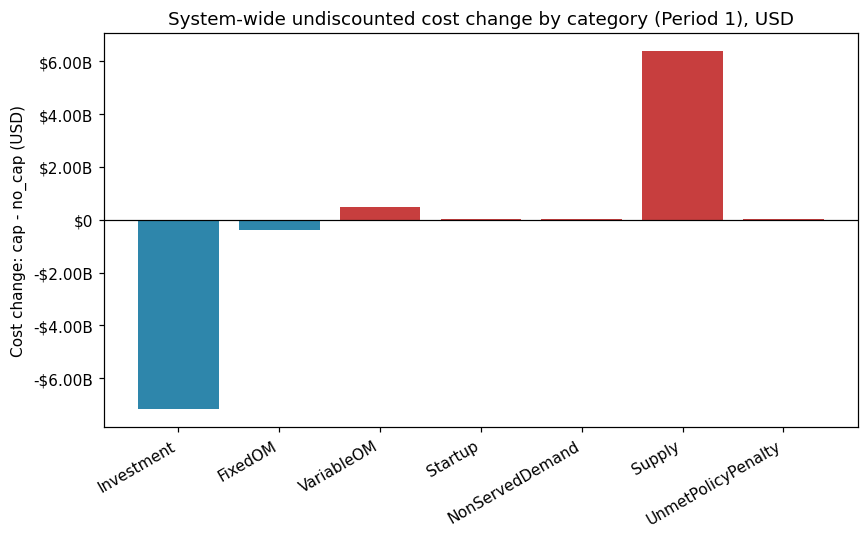

In [5]:
p = 1
cat_diff = summary.loc[p, [f"{c}_diff" for c in COST_COLS]]
cat_diff.index = COST_COLS

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#2E86AB" if v < 0 else "#C73E3E" for v in cat_diff.values]
ax.bar(cat_diff.index, cat_diff.values, color=colors)
ax.axhline(0, color="black", linewidth=0.8)
ax.yaxis.set_major_formatter(USD)
ax.set_ylabel("Cost change: cap - no_cap (USD)")
ax.set_title(f"System-wide undiscounted cost change by category (Period {p}), USD")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## Total system cost across all four periods

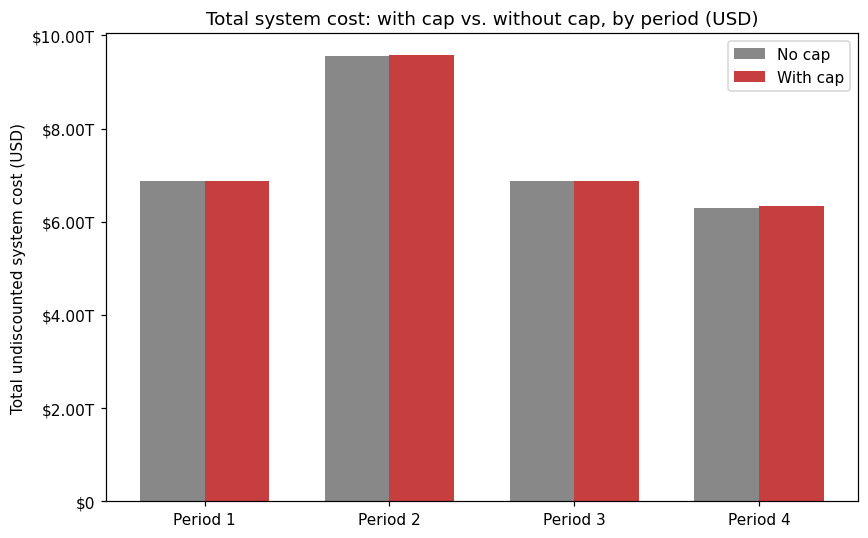

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(PERIODS))
width = 0.35
ax.bar(x - width / 2, summary["Total_no_cap"], width, label="No cap", color="#888888")
ax.bar(x + width / 2, summary["Total_cap"], width, label="With cap", color="#C73E3E")
ax.set_xticks(x)
ax.set_xticklabels([f"Period {p}" for p in PERIODS])
ax.yaxis.set_major_formatter(USD)
ax.set_ylabel("Total undiscounted system cost (USD)")
ax.set_title("Total system cost: with cap vs. without cap, by period (USD)")
ax.legend()
plt.tight_layout()
plt.show()

## Top zones/nodes by absolute cost change (Period 1)

In [7]:
p = 1
order = comparisons[p]["Total_diff"].abs().sort_values(ascending=False).index
top20 = comparisons[p].reindex(order).head(20)
top20[["Total_cap", "Total_no_cap", "Total_diff", "Total_pct_change"]]

,Total_cap,Total_no_cap,Total_diff,Total_pct_change
zone,,,,
Region3Hebei_bfbof_transforms_crudesteel_Region3Hebei,0.0000e+00,1.8895e+10,-1.8895e+10,-1.0000e+02
Region3Hebei,1.3746e+11,1.2107e+11,1.6385e+10,1.3533e+01
Region10Jiangsu,1.6544e+11,1.5605e+11,9.3840e+09,6.0134e+00
Region10Jiangsu_bfbof_transforms_crudesteel_Region10Jiangsu,0.0000e+00,9.2455e+09,-9.2455e+09,-1.0000e+02
steelscrap_source_Region19Guangdong,1.2304e+10,5.2465e+09,7.0573e+09,1.3451e+02
Region25Yunnan_bfbof_transforms_crudesteel_Region25Yunnan,0.0000e+00,6.6850e+09,-6.6850e+09,-1.0000e+02
Region6Liaoning,1.1074e+10,4.9986e+09,6.0751e+09,1.2154e+02
Region6Liaoning_bfbof_transforms_crudesteel_Region6Liaoning,0.0000e+00,6.0445e+09,-6.0445e+09,-1.0000e+02
Region4Shanxi,1.2715e+11,1.2180e+11,5.3540e+09,4.3958e+00


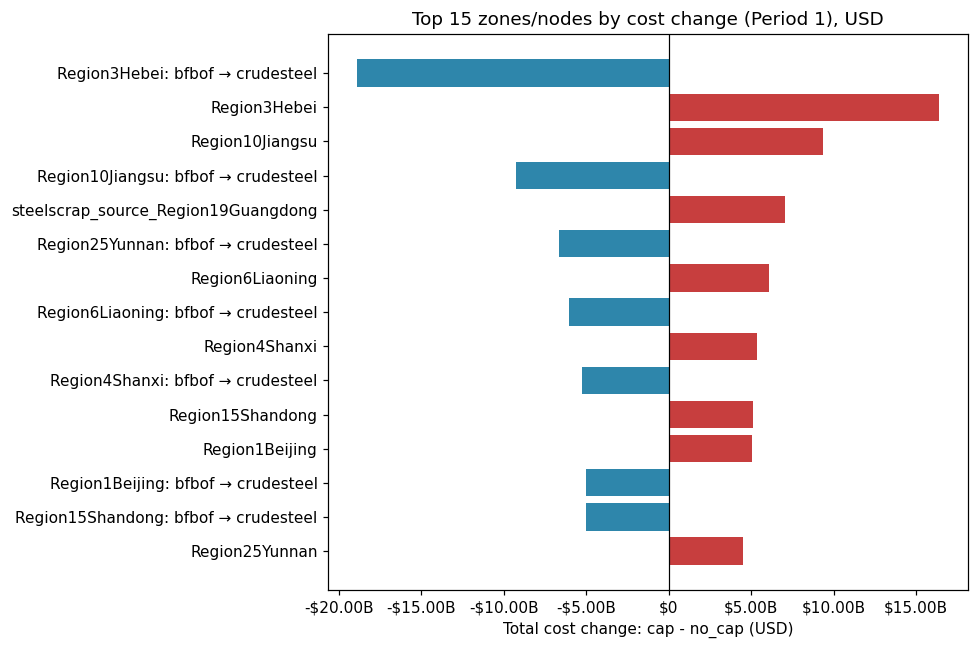

In [8]:
p = 1
top15 = comparisons[p].reindex(order).head(15)

import re

_TECH_PATTERN = re.compile(
    r"^(?P<region>Region\d+[A-Za-z]+)_(?P<tech>[A-Za-z0-9]+)_transforms_(?P<product>[A-Za-z0-9]+)_(?P=region)$"
)

def short_label(zone, maxlen=42):
    """Collapse the repetitive `RegionX_tech_transforms_product_RegionX`
    node names down to `RegionX: tech -> product`; truncate anything else
    long so the chart stays legible."""
    m = _TECH_PATTERN.match(zone)
    if m:
        return f"{m['region']}: {m['tech']} \u2192 {m['product']}"
    return zone if len(zone) <= maxlen else zone[: maxlen - 1] + "\u2026"

labels = [short_label(z) for z in top15.index[::-1]]

fig, ax = plt.subplots(figsize=(9, 6))
colors = ["#2E86AB" if v < 0 else "#C73E3E" for v in top15["Total_diff"].values]
ax.barh(labels, top15["Total_diff"].values[::-1], color=colors[::-1])
ax.axvline(0, color="black", linewidth=0.8)
ax.xaxis.set_major_formatter(USD)
ax.set_xlabel("Total cost change: cap - no_cap (USD)")
ax.set_title(f"Top 15 zones/nodes by cost change (Period {p}), USD")
plt.tight_layout()
plt.show()

## Geographic view: cost by province (Period 1)

The bar charts above are hard to read at a glance because "zone" mixes the
31 provincial electricity zones with thousands of commodity, technology, and
transmission nodes (`aluminum_Region1Beijing_aluminum_Region2Tianjin`,
`Region3Hebei_bfbof_transforms_crudesteel_Region3Hebei`, ...), so the x-axis
labels don't mean much on their own.

This section instead maps just the **31 provincial electricity zones**
directly onto China, using
[`ck0997/macro_plotting`](https://github.com/ck0997/macro_plotting/tree/main/plotting_software)
(vendored locally under `plotting_software/`, since it isn't a published
package). Each pie is sized by that province's total undiscounted cost and
colored by cost category — so you can see both **where** the money is spent
and **what it's spent on**, geographically.

In [9]:
import sys

sys.path.insert(0, str(BASE))
from plotting_software import plot_pie_map, plot_quantity_map, load_province_geodata

_PROVINCE_ROW = re.compile(r"^Region\d+([A-Za-z]+)$")

def province_costs(df, cols):
    """Reduce a full zone-level cost table to the 31 provincial electricity
    zones, indexed by bare province name (matching the map boundaries),
    dropping every commodity/transmission/CO2-transport/technology node."""
    matches = df.index.to_series().str.extract(_PROVINCE_ROW)[0]
    out = df.loc[matches.notna(), cols].copy()
    out.index = matches.dropna()
    out.index.name = "province"
    return out

gdf = load_province_geodata()
print(f"{len(gdf)} provinces loaded from the map boundary file")

31 provinces loaded from the map boundary file


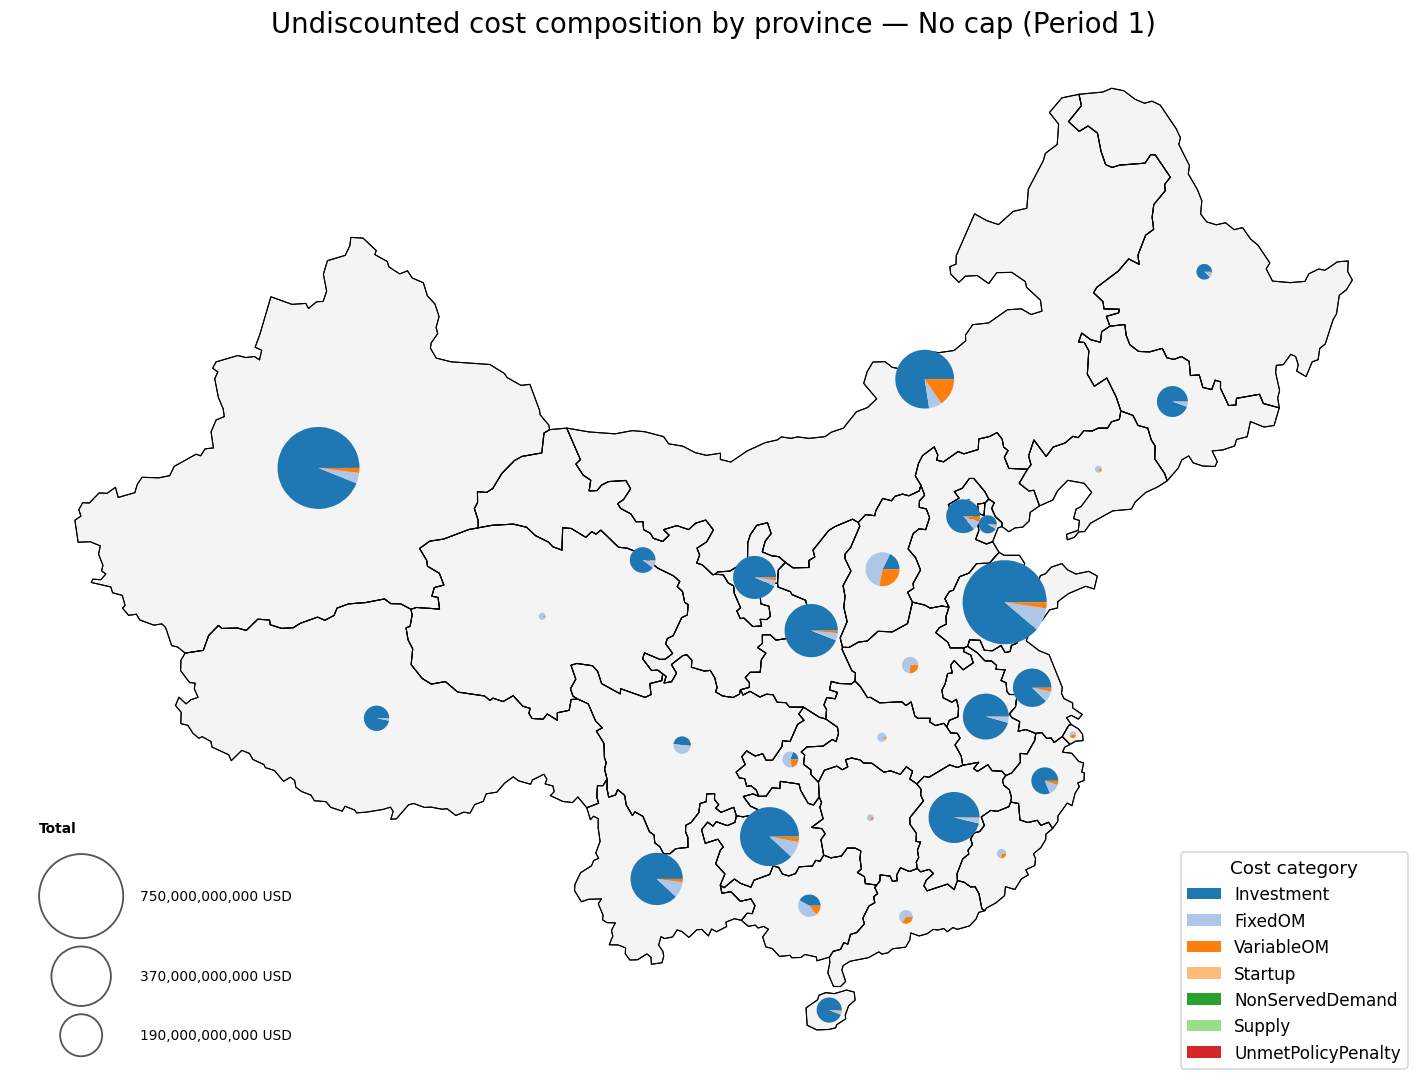

In [10]:
p = 1
no_cap_by_province = province_costs(no_cap[p], COST_COLS)
plot_pie_map(
    no_cap_by_province,
    gdf=gdf,
    title=f"Undiscounted cost composition by province \u2014 No cap (Period {p})",
    unit_label="USD",
    legend_title="Cost category",
    show=True,
);

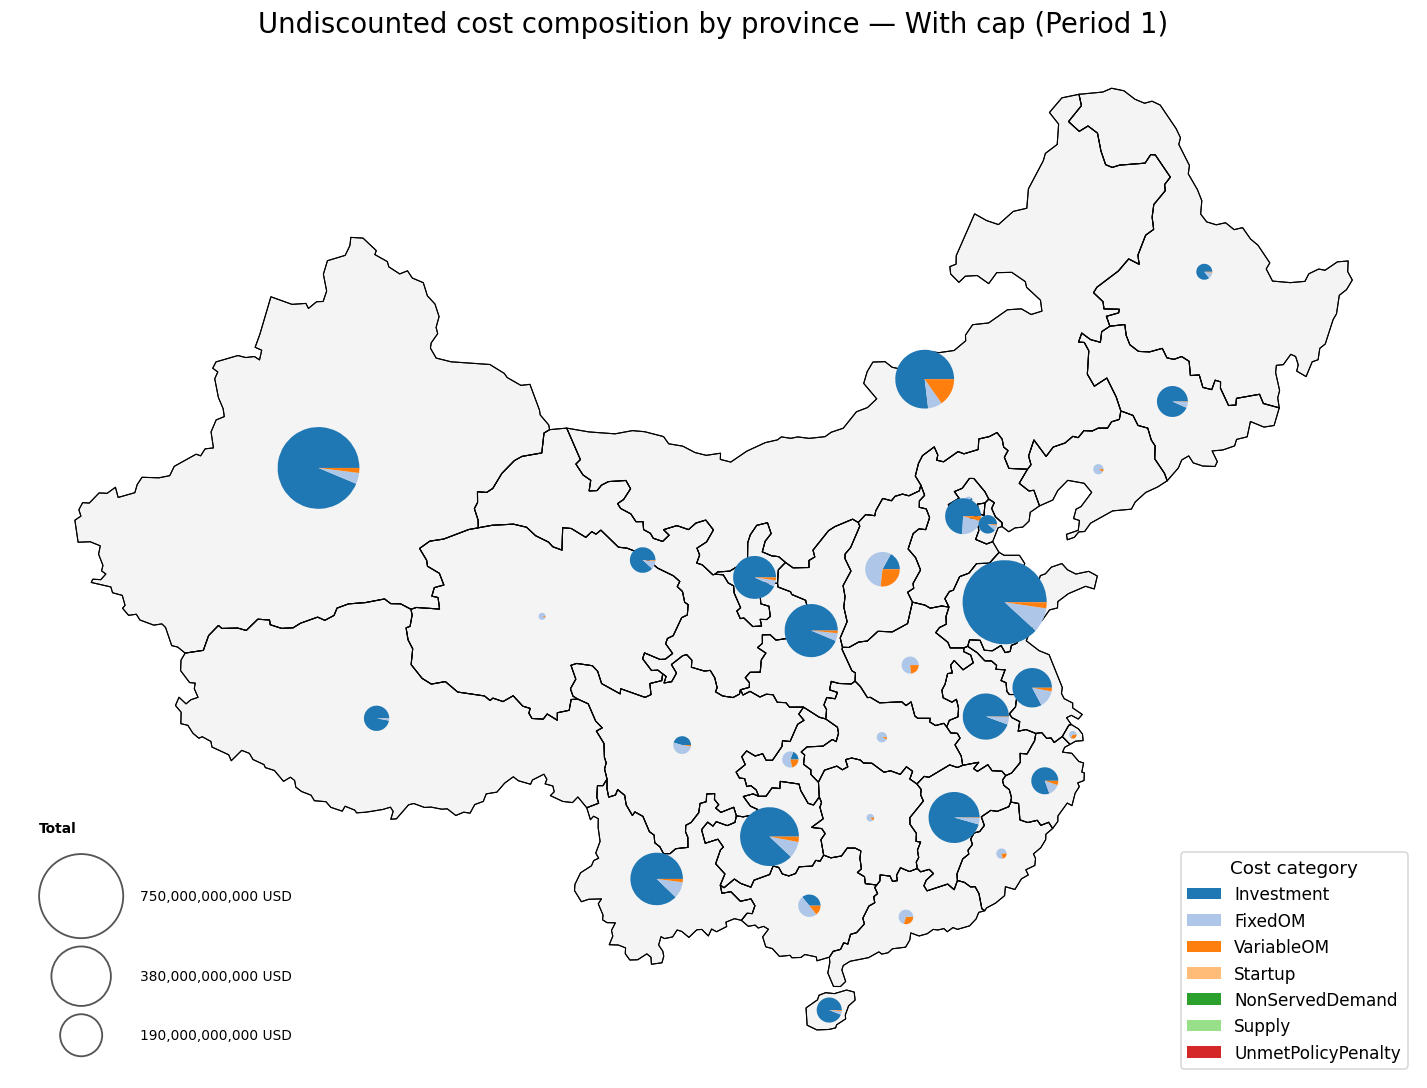

In [11]:
cap_by_province = province_costs(cap[p], COST_COLS)
plot_pie_map(
    cap_by_province,
    gdf=gdf,
    title=f"Undiscounted cost composition by province \u2014 With cap (Period {p})",
    unit_label="USD",
    legend_title="Cost category",
    show=True,
);

### Where does the cap raise or lower cost?

`plot_quantity_map` only supports non-negative values (a circle can't
represent a negative amount), so the diff is split into two maps: provinces
where the cap makes total cost go **up**, and provinces where it goes
**down**. Circle area is proportional to the size of the change.

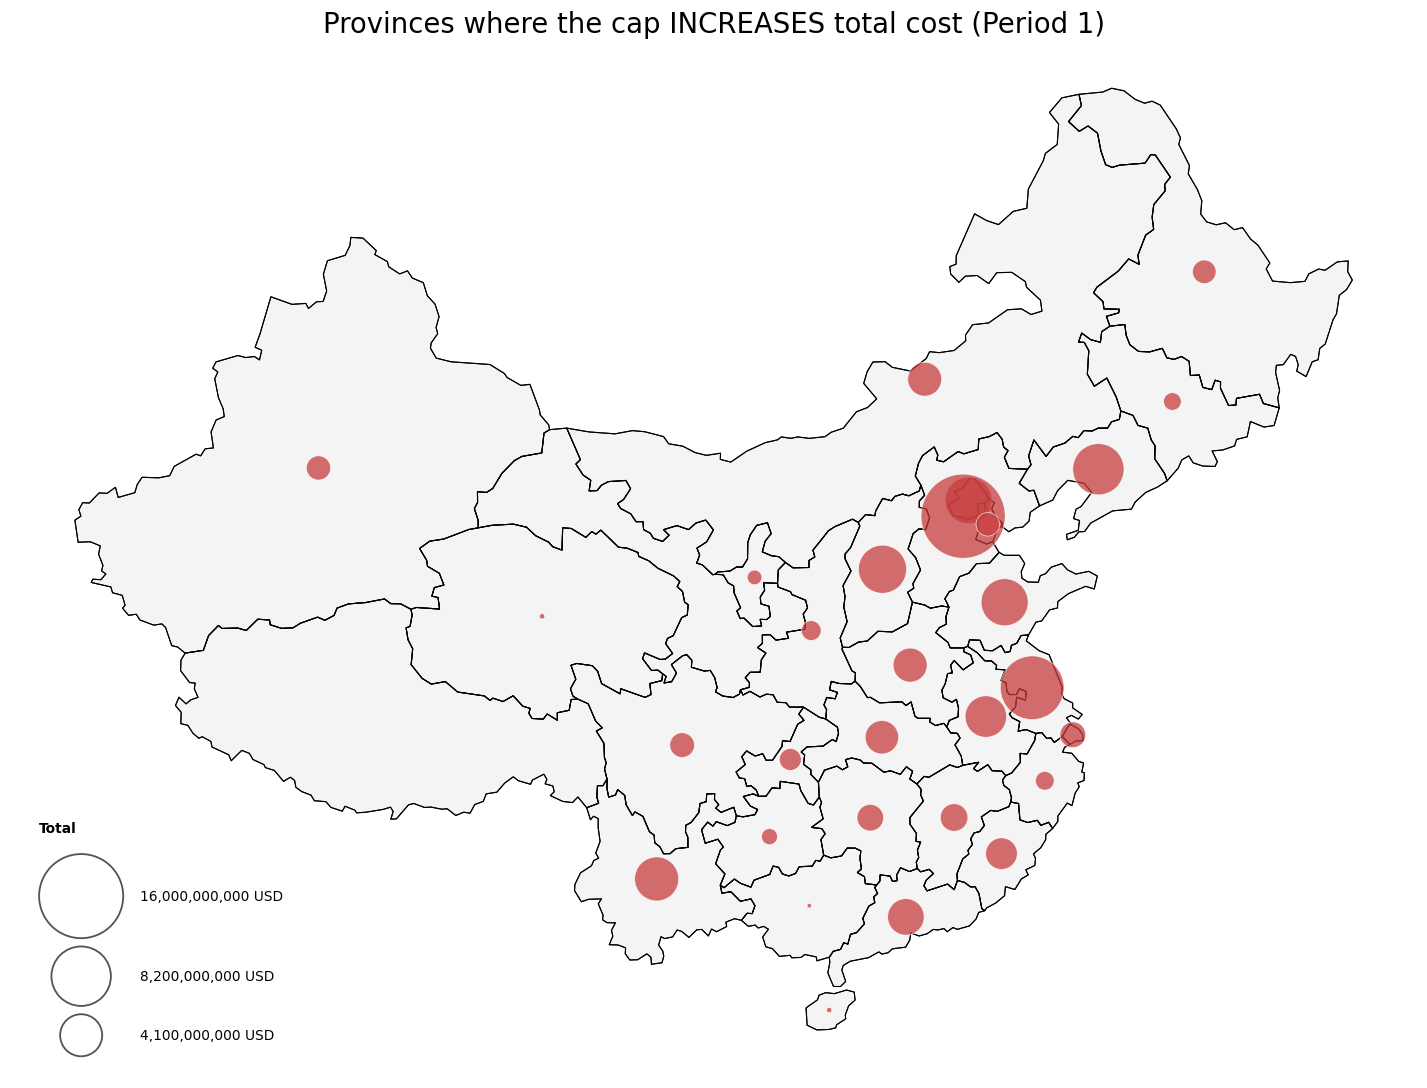

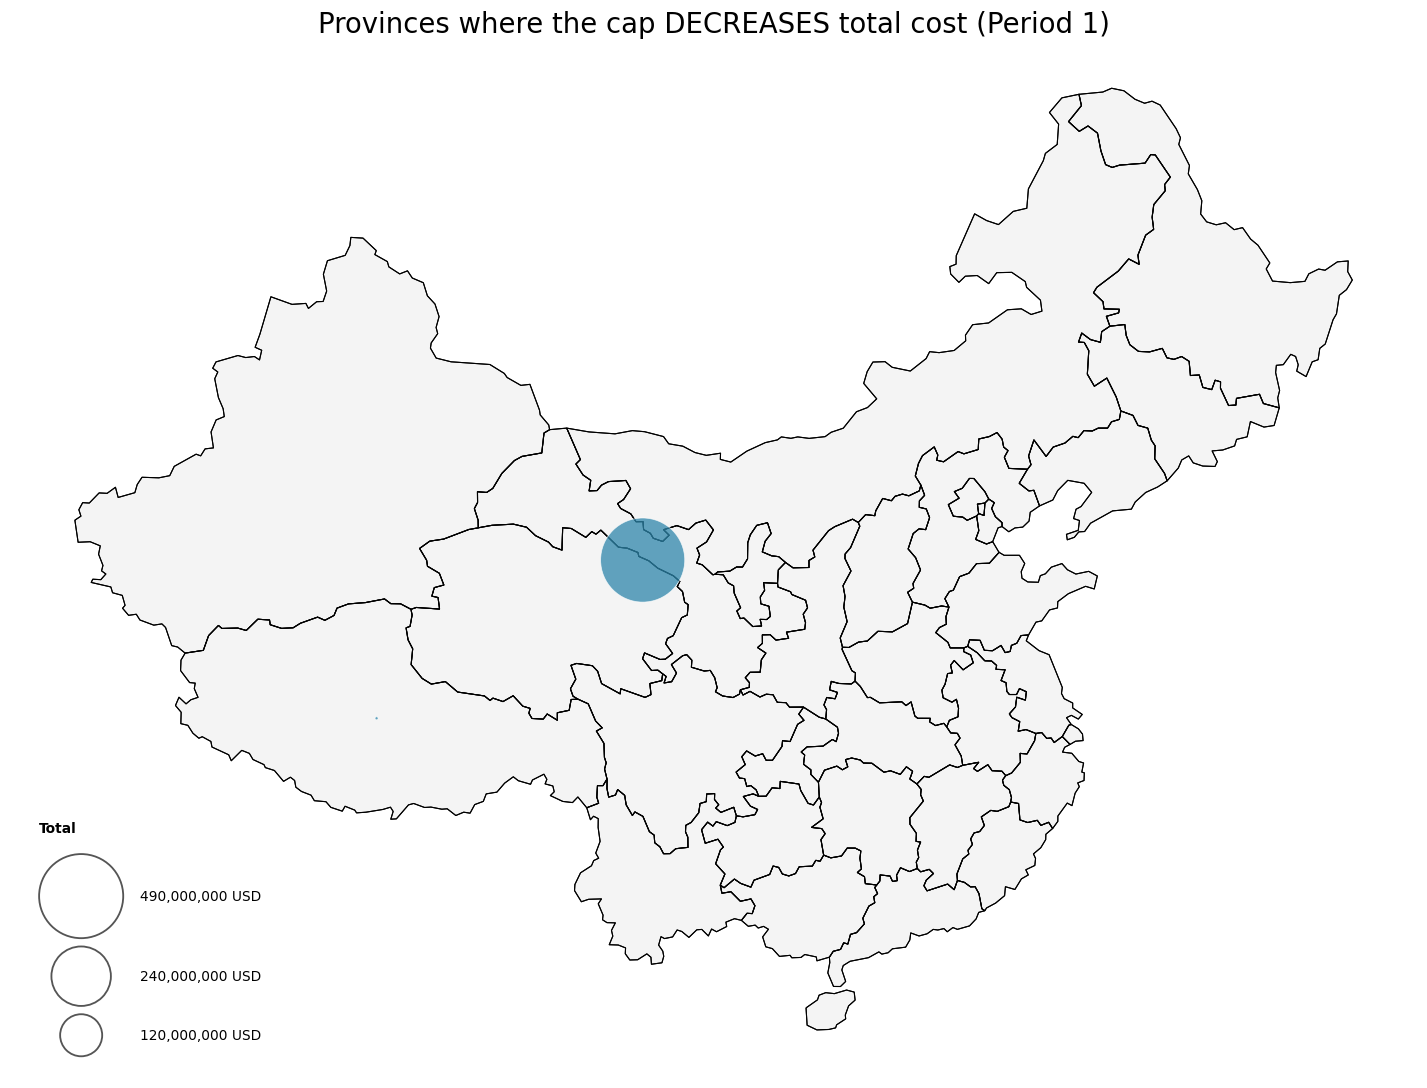

In [12]:
cap_total = province_costs(cap[p], ["Total"])["Total"]
no_cap_total = province_costs(no_cap[p], ["Total"])["Total"]
diff_total = (cap_total - no_cap_total).reindex(no_cap_total.index).fillna(0)

increase = diff_total.clip(lower=0)
decrease = (-diff_total).clip(lower=0)

plot_quantity_map(
    increase, gdf=gdf, color="#C73E3E",
    title=f"Provinces where the cap INCREASES total cost (Period {p})",
    unit_label="USD", show=True,
);
plot_quantity_map(
    decrease, gdf=gdf, color="#2E86AB",
    title=f"Provinces where the cap DECREASES total cost (Period {p})",
    unit_label="USD", show=True,
);

## Nodes present in only one scenario

The cap and no-cap runs don't have identical node sets — some technology options
(e.g. certain crude-steel production routes) only appear when the cap is *not*
applied, meaning the cap constraint makes them infeasible/unused.

In [13]:
p = 1
only_no_cap = comparisons[p][(comparisons[p]["Total_cap"] == 0) & (comparisons[p]["Total_no_cap"] != 0)]
only_cap = comparisons[p][(comparisons[p]["Total_no_cap"] == 0) & (comparisons[p]["Total_cap"] != 0)]

print(f"Nodes present only WITHOUT the cap: {len(only_no_cap)}")
print(f"Nodes present only WITH the cap:    {len(only_cap)}")

only_no_cap[["Total_no_cap"]].sort_values("Total_no_cap", ascending=False).head(15)

Nodes present only WITHOUT the cap: 145
Nodes present only WITH the cap:    0


,Total_no_cap
zone,
Region3Hebei_bfbof_transforms_crudesteel_Region3Hebei,1.8895e+10
Region10Jiangsu_bfbof_transforms_crudesteel_Region10Jiangsu,9.2455e+09
Region25Yunnan_bfbof_transforms_crudesteel_Region25Yunnan,6.6850e+09
Region6Liaoning_bfbof_transforms_crudesteel_Region6Liaoning,6.0445e+09
Region4Shanxi_bfbof_transforms_crudesteel_Region4Shanxi,5.2823e+09
Region1Beijing_bfbof_transforms_crudesteel_Region1Beijing,5.0221e+09
Region15Shandong_bfbof_transforms_crudesteel_Region15Shandong,5.0217e+09
Region20Guangxi_bfbof_transforms_crudesteel_Region20Guangxi,3.4098e+09
Region12Anhui_bfbof_transforms_crudesteel_Region12Anhui,2.9210e+09


In [14]:
# Group the cap-excluded nodes by technology (crude-steel production route)
only_no_cap_named = only_no_cap.copy()
only_no_cap_named["technology"] = (
    only_no_cap_named.index.to_series().str.extract(r"_(\w+)_transforms_crudesteel_")[0]
)
tech_summary = (
    only_no_cap_named.dropna(subset=["technology"])
    .groupby("technology")["Total_no_cap"]
    .agg(["count", "sum"])
    .sort_values("sum", ascending=False)
)
tech_summary

,count,sum
technology,,
bfbof,29,9.0839e+10
scrapeaf56,29,4.9689e+08
drieaf,29,7.8076e+06
bfbofccs,29,1.8471e+06
scrapeaf100,29,6.7701e+04


## Save the detailed Period 1 comparison to CSV

In [15]:
out_path = BASE / "cap_vs_no_cap_comparison_period1.csv"
comparisons[1].to_csv(out_path)
print(f"Saved detailed comparison to {out_path}")

Saved detailed comparison to /Users/chinnykwok/hmei/Net_Zero_China/NZC_Workshop_Example_Systems_June_2026/NZC_Workshop_All Sector_12day_MultiPeriods_WIP/case/results_tdr12days_062026/cap_vs_no_cap_comparison_period1.csv


---
# Steel-only cost comparison: with cap (`by_id`) vs no cap (`by_zone`)

The zone-level file used above (`undiscounted_costs_by_zone.csv`) has a data
gap for the **with-cap** scenario: steelmaking technology costs
(`RegionX_bfbof_transforms_crudesteel_RegionX` and friends) are missing
entirely from that file for the cap runs, which is why every steel row showed
up as "-100% / only present without cap" in the sections above — that's a
data artifact, not a real economic result.

`undiscounted_costs_by_id.csv` (available for all 4 cap periods) fixes this:
it reports costs per resource id, e.g. `Region1Beijing_bfbof`,
`Region1Beijing_bfbofccs`, `Region1Beijing_drieaf`,
`Region1Beijing_scrapeaf56`, `Region1Beijing_scrapeaf100` — the same 5
steelmaking process routes, one row per province, with real (non-zero) cost
data.

No equivalent `by_id` file exists for the no-cap scenario, so the no-cap side
below still comes from `undiscounted_costs_by_zone.csv`, using its
`RegionX_<tech>_transforms_crudesteel_RegionX` naming. Both sides are
reduced to the same `(province, technology)` key so they can be compared
directly.


In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from pathlib import Path

BASE = Path(
    "/Users/chinnykwok/hmei/Net_Zero_China/NZC_Workshop_Example_Systems_June_2026/"
    "NZC_Workshop_All Sector_12day_MultiPeriods_WIP/case/results_tdr12days_062026"
)
PERIODS = [1, 2, 3, 4]
COST_COLS = [
    "Investment", "FixedOM", "VariableOM", "Startup",
    "NonServedDemand", "Supply", "UnmetPolicyPenalty",
]

def _usd(x, pos=None):
    sign = "-" if x < 0 else ""
    x = abs(x)
    if x >= 1e12:
        return f"{sign}${x / 1e12:.2f}T"
    if x >= 1e9:
        return f"{sign}${x / 1e9:.2f}B"
    if x >= 1e6:
        return f"{sign}${x / 1e6:.2f}M"
    if x >= 1e3:
        return f"{sign}${x / 1e3:.2f}K"
    return f"{sign}${x:.0f}"

USD = FuncFormatter(_usd)

STEEL_TECHS = ["bfbof", "bfbofccs", "drieaf", "scrapeaf56", "scrapeaf100"]
_TECH_ALT = "|".join(STEEL_TECHS)

# with-cap: bare resource id, e.g. "Region1Beijing_bfbof"
_STEEL_ID_CAP = re.compile(rf"^(?P<province>Region\d+[A-Za-z]+)_(?P<technology>{_TECH_ALT})$")
# no-cap: transformation-edge id, e.g. "Region1Beijing_bfbof_transforms_crudesteel_Region1Beijing"
_STEEL_ID_NOCAP = re.compile(
    rf"^(?P<province>Region\d+[A-Za-z]+)_(?P<technology>{_TECH_ALT})_transforms_crudesteel_(?P=province)$"
)

def load_steel_cap(period):
    df = pd.read_csv(BASE / f"results_period_{period}" / "undiscounted_costs_by_id.csv")
    df = df[df["id"] != "Total"]
    m = df["id"].str.extract(_STEEL_ID_CAP)
    steel = df.loc[m["province"].notna(), COST_COLS + ["Total"]].copy()
    steel[["province", "technology"]] = m.loc[m["province"].notna()]
    return steel.set_index(["province", "technology"])

def load_steel_no_cap(period):
    df = pd.read_csv(BASE / f"no_cap_results_period_{period}" / "undiscounted_costs_by_zone.csv")
    df = df[df["zone"] != "Total"]
    m = df["zone"].str.extract(_STEEL_ID_NOCAP)
    steel = df.loc[m["province"].notna(), COST_COLS + ["Total"]].copy()
    steel[["province", "technology"]] = m.loc[m["province"].notna()]
    return steel.set_index(["province", "technology"])

steel_cap = {p: load_steel_cap(p) for p in PERIODS}
steel_no_cap = {p: load_steel_no_cap(p) for p in PERIODS}

print("Steel rows (province x technology) per period — expect 29 provinces x 5 techs = 145:")
for p in PERIODS:
    print(f"  period {p}: cap={len(steel_cap[p])}, no_cap={len(steel_no_cap[p])}")


Steel rows (province x technology) per period — expect 29 provinces x 5 techs = 145:
  period 1: cap=145, no_cap=145
  period 2: cap=145, no_cap=145
  period 3: cap=145, no_cap=145
  period 4: cap=145, no_cap=145


## Steel cost comparison by province and technology

In [2]:
def compare_steel(period):
    c = steel_cap[period][COST_COLS + ["Total"]]
    n = steel_no_cap[period][COST_COLS + ["Total"]]
    merged = c.join(n, how="outer", lsuffix="_cap", rsuffix="_no_cap").fillna(0.0)
    for col in COST_COLS + ["Total"]:
        merged[f"{col}_diff"] = merged[f"{col}_cap"] - merged[f"{col}_no_cap"]
    merged["Total_pct_change"] = np.where(
        merged["Total_no_cap"] != 0,
        merged["Total_diff"] / merged["Total_no_cap"] * 100,
        np.nan,
    )
    return merged

steel_comparisons = {p: compare_steel(p) for p in PERIODS}
steel_comparisons[1][["Total_cap", "Total_no_cap", "Total_diff", "Total_pct_change"]].sort_values(
    "Total_diff", ascending=False
).head(15)


,,Total_cap,Total_no_cap,Total_diff,Total_pct_change
province,technology,,,,
Region19Guangdong,scrapeaf56,1.179976e+08,1.101855e+08,7.812183e+06,7.090031
Region25Yunnan,drieaf,1.674865e+06,2.962728e+05,1.378593e+06,465.311990
Region24Guizhou,drieaf,1.661895e+06,6.959559e+05,9.659391e+05,138.793143
Region11Zhejiang,drieaf,1.047895e+06,1.421602e+05,9.057352e+05,637.122805
Region19Guangdong,drieaf,1.668223e+06,8.605166e+05,8.077061e+05,93.862924
Region9Shanghai,drieaf,4.698624e+05,7.728641e+04,3.925760e+05,507.949523
Region15Shandong,bfbof,5.021980e+09,5.021716e+09,2.637595e+05,0.005252
Region20Guangxi,drieaf,2.141822e+05,4.562230e+03,2.096200e+05,4594.682031
Region12Anhui,drieaf,5.079480e+05,3.828807e+05,1.250673e+05,32.664813


## Steel system-wide totals: cap vs. no-cap, by period

In [3]:
steel_summary_rows = []
for p in PERIODS:
    c_tot = steel_cap[p][COST_COLS + ["Total"]].sum()
    n_tot = steel_no_cap[p][COST_COLS + ["Total"]].sum()
    row = {"period": p}
    for col in COST_COLS + ["Total"]:
        row[f"{col}_cap"] = c_tot[col]
        row[f"{col}_no_cap"] = n_tot[col]
        row[f"{col}_diff"] = c_tot[col] - n_tot[col]
    steel_summary_rows.append(row)
steel_summary = pd.DataFrame(steel_summary_rows).set_index("period")

steel_totals = steel_summary[["Total_cap", "Total_no_cap", "Total_diff"]].copy()
steel_totals["pct_change"] = steel_totals["Total_diff"] / steel_totals["Total_no_cap"] * 100
steel_totals


,Total_cap,Total_no_cap,Total_diff,pct_change
period,,,,
1,9.133325e+10,9.134530e+10,-1.204828e+07,-0.013190
2,1.502885e+11,1.502871e+11,1.388647e+06,0.000924
3,1.394659e+11,1.394830e+11,-1.711643e+07,-0.012271
4,2.229845e+11,2.229835e+11,1.098657e+06,0.000493


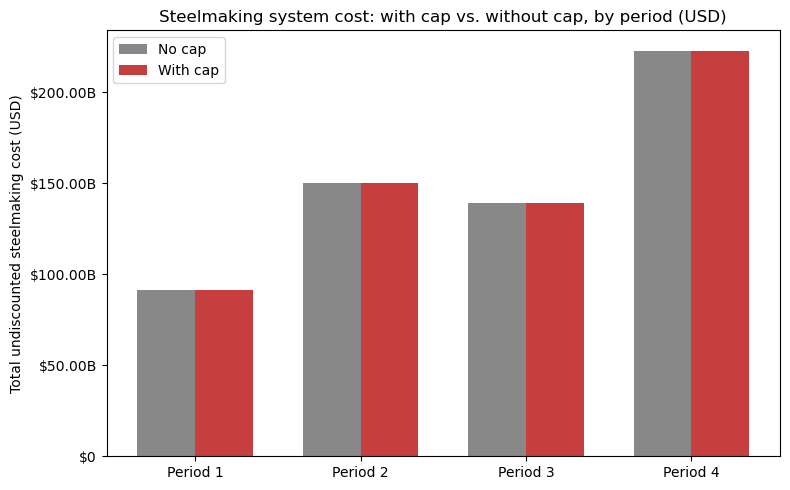

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(PERIODS))
width = 0.35
ax.bar(x - width / 2, steel_summary["Total_no_cap"], width, label="No cap", color="#888888")
ax.bar(x + width / 2, steel_summary["Total_cap"], width, label="With cap", color="#C73E3E")
ax.set_xticks(x)
ax.set_xticklabels([f"Period {p}" for p in PERIODS])
ax.yaxis.set_major_formatter(USD)
ax.set_ylabel("Total undiscounted steelmaking cost (USD)")
ax.set_title("Steelmaking system cost: with cap vs. without cap, by period (USD)")
ax.legend()
plt.tight_layout()
plt.show()


## Steel cost by process route (technology), summed across provinces

In [5]:
tech_rows = []
for p in PERIODS:
    c_by_tech = steel_cap[p]["Total"].groupby("technology").sum()
    n_by_tech = steel_no_cap[p]["Total"].groupby("technology").sum()
    for tech in STEEL_TECHS:
        tech_rows.append({
            "period": p,
            "technology": tech,
            "Total_cap": c_by_tech.get(tech, 0.0),
            "Total_no_cap": n_by_tech.get(tech, 0.0),
        })
tech_by_period = pd.DataFrame(tech_rows)
tech_by_period["Total_diff"] = tech_by_period["Total_cap"] - tech_by_period["Total_no_cap"]
tech_by_period["Total_pct_change"] = np.where(
    tech_by_period["Total_no_cap"] != 0,
    tech_by_period["Total_diff"] / tech_by_period["Total_no_cap"] * 100,
    np.nan,
)
tech_by_period.set_index(["period", "technology"])


Total_cap  Total_no_cap    Total_diff  Total_pct_change
period technology                                                             
1      bfbof        9.082593e+10  9.083868e+10 -1.275068e+07         -0.014037
       bfbofccs     4.932210e+05  1.847063e+06 -1.353842e+06        -73.297016
       drieaf       9.054596e+06  7.807551e+06  1.247046e+06         15.972307
       scrapeaf56   4.977514e+08  4.968947e+08  8.567456e+05          0.172420
       scrapeaf100  2.014538e+04  6.770119e+04 -4.755581e+04        -70.243687
2      bfbof        1.441812e+11  1.441825e+11 -1.291097e+06         -0.000895
       bfbofccs     5.888281e+05  2.181319e+06 -1.592491e+06        -73.005867
       drieaf       6.106440e+09  6.101493e+09  4.946481e+06          0.081070
       scrapeaf56   1.513361e+05  4.001009e+05 -2.487648e+05        -62.175519
       scrapeaf100  1.640226e+05  5.895034e+05 -4.254809e+05        -72.176149
3      bfbof        1.265251e+11  1.265113e+11  1.384674e+07          0.010945
       bfbofccs     7.567263e+04  3.198347e+06 -3.122674e+06        -97.634008
       drieaf       1.293855e+10  1.296748e+10 -2.892504e+07         -0.223058
       scrapeaf56   8.230640e+04  6.911342e+04  1.319298e+04         19.088884
       scrapeaf100  2.072755e+06  1.001401e+06  1.071354e+06        106.985578
4      bfbof        3.790146e+04  5.384210e+04 -1.594065e+04        -29.606284
       bfbofccs     1.478434e+05  9.949438e+05 -8.471003e+05        -85.140523
       drieaf       2.134221e+11  2.134181e+11  3.989850e+06          0.001869
       scrapeaf56   4.420530e+04  6.112334e+04 -1.691804e+04        -27.678525
       scrapeaf100  9.562223e+09  9.564235e+09 -2.011235e+06         -0.021029

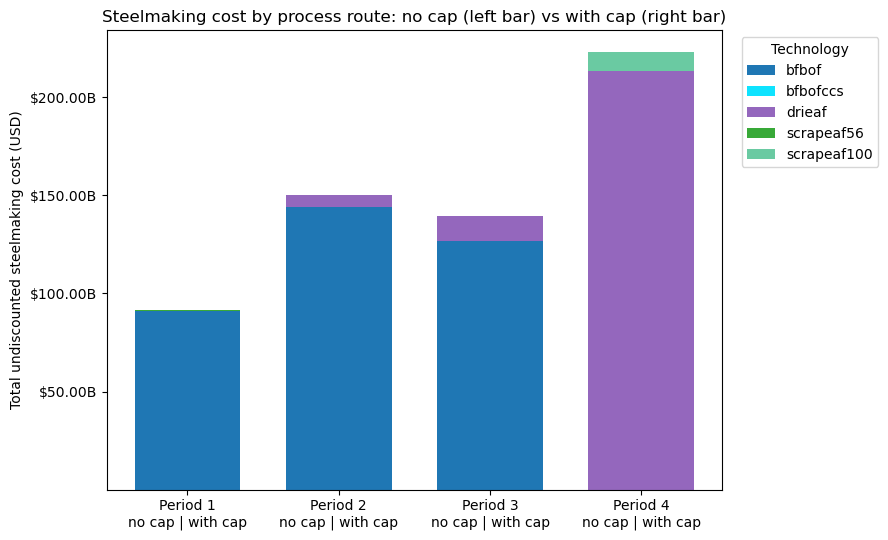

In [6]:
TECH_COLORS = {
    "bfbof": "#1f77b4",
    "bfbofccs": "#0ee3ff",
    "scrapeaf56": "#38a938",
    "scrapeaf100": "#6acaa2",
    "drieaf": "#9467bd",
}

fig, ax = plt.subplots(figsize=(9, 5.5))
x = np.arange(len(PERIODS))
width = 0.35

bottom_cap = np.zeros(len(PERIODS))
bottom_no_cap = np.zeros(len(PERIODS))
for tech in STEEL_TECHS:
    vals_cap = tech_by_period[tech_by_period["technology"] == tech].set_index("period")["Total_cap"].reindex(PERIODS).values
    vals_no_cap = tech_by_period[tech_by_period["technology"] == tech].set_index("period")["Total_no_cap"].reindex(PERIODS).values
    ax.bar(x - width / 2, vals_no_cap, width, bottom=bottom_no_cap, color=TECH_COLORS[tech], label=tech)
    ax.bar(x + width / 2, vals_cap, width, bottom=bottom_cap, color=TECH_COLORS[tech])
    bottom_no_cap += vals_no_cap
    bottom_cap += vals_cap

ax.set_xticks(x)
ax.set_xticklabels([f"Period {p}\nno cap | with cap" for p in PERIODS])
ax.yaxis.set_major_formatter(USD)
ax.set_ylabel("Total undiscounted steelmaking cost (USD)")
ax.set_title("Steelmaking cost by process route: no cap (left bar) vs with cap (right bar)")
ax.legend(title="Technology", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


## Save the detailed steel comparison (all periods) to CSV

In [7]:
all_periods_steel = pd.concat(
    {p: steel_comparisons[p] for p in PERIODS}, names=["period"]
)
steel_out_path = BASE / "steel_cap_vs_no_cap_comparison_all_periods.csv"
all_periods_steel.to_csv(steel_out_path)
print(f"Saved steel-only comparison ({len(all_periods_steel)} rows, all periods) to {steel_out_path}")


Saved steel-only comparison (580 rows, all periods) to /Users/chinnykwok/hmei/Net_Zero_China/NZC_Workshop_Example_Systems_June_2026/NZC_Workshop_All Sector_12day_MultiPeriods_WIP/case/results_tdr12days_062026/steel_cap_vs_no_cap_comparison_all_periods.csv
